# Crash Vs Constructions


## Goal
Explore whether **construction activity** in NYC is associated with:
- Higher crash counts (time trends)
- Higher crash severity (injuries / fatalities)
- More crashes near construction locations (spatial proximity)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from urllib.parse import urlencode

pd.set_option("display.max_columns", 200)

In [2]:
start_date = pd.to_datetime("2015-01-01")
end_date   = pd.to_datetime("2025-12-31")
start_date, end_date

(Timestamp('2015-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [3]:
crash_raw = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes_20260204.csv", low_memory=False)

crash_raw["CRASH DATE"] = pd.to_datetime(crash_raw["CRASH DATE"], errors="coerce")
crash_raw["CRASH TIME"] = pd.to_datetime(crash_raw["CRASH TIME"], format="%H:%M", errors="coerce").dt.time

crashes = crash_raw.dropna(subset=["CRASH DATE"]).copy()
crashes = crashes[(crashes["CRASH DATE"] >= start_date) & (crashes["CRASH DATE"] <= end_date)].copy()

print("Crashes shape:", crashes.shape)
print("Crash range:", crashes["CRASH DATE"].min(), "→", crashes["CRASH DATE"].max())
crashes.head()

Crashes shape: (1722361, 29)
Crash range: 2015-01-01 00:00:00 → 2025-12-31 00:00:00


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,2021-09-11,02:39:00,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,2.0,0.0,0,0,0,0,2,0,Aggressive Driving/Road Rage,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,2022-03-26,11:45:00,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,1.0,0.0,0,0,0,0,1,0,Pavement Slippery,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,2023-11-01,01:29:00,BROOKLYN,11230,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,1.0,0.0,0,0,0,0,1,0,Unspecified,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,2022-06-29,06:55:00,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,0.0,0.0,0,0,0,0,0,0,Following Too Closely,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,2022-09-21,13:21:00,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,0.0,0.0,0,0,0,0,0,0,Passing Too Closely,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


In [4]:
base = "https://data.cityofnewyork.us/resource/ic3t-wcy2.csv"

select_cols = ",".join([
    "job__",
    "job_type",
    "borough",
    "gis_latitude",
    "gis_longitude",
    "pre__filing_date",
    "signoff_date"
])

limit = 50000
offset = 0
kept_chunks = []
max_pages = 40  # safety cap

for page in range(max_pages):
    params = {
        "$select": select_cols,
        "$limit": limit,
        "$offset": offset,
        "$order": "pre__filing_date DESC"
    }
    url = base + "?" + urlencode(params)

    chunk = pd.read_csv(url, low_memory=False)
    if chunk.empty:
        print("No more rows from API.")
        break

    chunk["construction_start"] = pd.to_datetime(chunk["pre__filing_date"], errors="coerce")
    chunk["construction_end"]   = pd.to_datetime(chunk["signoff_date"], errors="coerce")

    in_range = chunk[
        (chunk["construction_start"] >= start_date) &
        (chunk["construction_start"] <= end_date)
    ].copy()

    if not in_range.empty:
        kept_chunks.append(in_range)

    chunk_min = chunk["construction_start"].min()
    print(f"Page {page+1}: rows={len(chunk)}, kept={len(in_range)}, page_min_date={chunk_min}")

    if pd.notna(chunk_min) and chunk_min < start_date:
        print("Reached dates older than 2015. Stopping early.")
        break

    offset += limit

if len(kept_chunks) == 0:
    raise ValueError("No construction rows kept in 2015–2025. Check date parsing.")

construction = pd.concat(kept_chunks, ignore_index=True)
construction["year"] = construction["construction_start"].dt.year

print("Construction shape:", construction.shape)
print("Construction range:", construction["construction_start"].min(), "→", construction["construction_start"].max())
construction.head()

Page 1: rows=50000, kept=16366, page_min_date=2000-12-22 00:00:00
Reached dates older than 2015. Stopping early.
Construction shape: (16366, 10)
Construction range: 2015-12-22 00:00:00 → 2025-12-31 00:00:00


,job__,job_type,borough,gis_latitude,gis_longitude,pre__filing_date,signoff_date,construction_start,construction_end,year
0,440827438,A3,QUEENS,40.746987,-73.902777,12/31/2025,NaN,2025-12-31,NaT,2025
1,440827447,A3,QUEENS,40.741260,-73.852004,12/31/2025,NaN,2025-12-31,NaT,2025
2,123919607,A3,MANHATTAN,40.753604,-74.004656,12/31/2025,NaN,2025-12-31,NaT,2025
3,421134463,SI,QUEENS,40.707612,-73.817586,12/31/2025,NaN,2025-12-31,NaT,2025
4,421844240,SC,QUEENS,40.760281,-73.832495,12/31/2025,NaN,2025-12-31,NaT,2025


In [5]:
construction["construction_start"].dt.year.value_counts().sort_index()

construction_start
2015    3390
2016    3151
2017    2278
2018    2074
2019    1747
2020    2242
2021     853
2022     390
2023      77
2024      80
2025      84
Name: count, dtype: int64

In [6]:
year_counts = construction["construction_start"].dt.year.value_counts().sort_index()
display(year_counts)

# Define "reliable" years as having at least 1000 records (tweak threshold if needed)
reliable_years = year_counts[year_counts >= 1000].index.tolist()
reliable_years

construction_start
2015    3390
2016    3151
2017    2278
2018    2074
2019    1747
2020    2242
2021     853
2022     390
2023      77
2024      80
2025      84
Name: count, dtype: int64

[2015, 2016, 2017, 2018, 2019, 2020]

## Overlap window for fair comparison

Construction data is sparse after 2020, so we restrict crash-vs-construction comparisons
to the years where construction coverage is reliable.

In [7]:
overlap_start = pd.to_datetime(f"{min(reliable_years)}-01-01")
overlap_end   = pd.to_datetime(f"{max(reliable_years)}-12-31")

crashes_overlap = crashes[(crashes["CRASH DATE"] >= overlap_start) & (crashes["CRASH DATE"] <= overlap_end)].copy()
construction_overlap = construction[(construction["construction_start"] >= overlap_start) & (construction["construction_start"] <= overlap_end)].copy()

print("Overlap period:", overlap_start.date(), "→", overlap_end.date())
print("Crashes overlap:", crashes_overlap.shape)
print("Construction overlap:", construction_overlap.shape)

Overlap period: 2015-01-01 → 2020-12-31
Crashes overlap: (1234514, 29)
Construction overlap: (14882, 10)


## Feature engineering: Construction job type

We will:
- clean `job_type`
- create a grouped variable `job_type_group` so results are interpretable
Then we can run the same EDA for:
1) All construction
2) By job type (A1/A2/A3/NB/Other…)

In [8]:
# Clean job_type
construction_overlap["job_type_clean"] = (
    construction_overlap["job_type"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Group job types (adjust later after we see your unique values)
def map_job_type(x):
    if x in ["A1", "A2", "A3"]:
        return "Alteration (A1/A2/A3)"
    if x in ["NB"]:
        return "New Building (NB)"
    if x in ["DM"]:
        return "Demolition (DM)"
    if x in ["NA", "N/A", "NONE", "UNKNOWN", "<NA>"]:
        return "Unknown"
    return "Other"

construction_overlap["job_type_group"] = construction_overlap["job_type_clean"].apply(map_job_type)

# Show what job types exist in your overlap window
job_counts = construction_overlap["job_type_clean"].value_counts(dropna=False)
display(job_counts)

group_counts = construction_overlap["job_type_group"].value_counts(dropna=False)
display(group_counts)

job_type_clean
A2    10100
A3     1897
A1     1226
NB      964
DM      448
SC      108
PA       76
SI       63
Name: count, dtype: Int64

job_type_group
Alteration (A1/A2/A3)    13223
New Building (NB)          964
Demolition (DM)            448
Other                      247
Name: count, dtype: int64

In [9]:
import pandas as pd
from urllib.parse import urlencode

# --- Settings ---
start_date = pd.to_datetime("2015-01-01")
end_date   = pd.to_datetime("2025-12-31")

base = "https://data.cityofnewyork.us/resource/ic3t-wcy2.csv"
select_cols = ",".join([
    "job__",
    "job_type",
    "borough",
    "gis_latitude",
    "gis_longitude",
    "pre__filing_date",
    "signoff_date"
])

def parse_socrata_dates(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.strip()

    formats = [
        "%m/%d/%Y",
        "%m/%d/%Y %H:%M:%S",
        "%Y-%m-%d",
        "%Y-%m-%dT%H:%M:%S.%f",
        "%Y-%m-%dT%H:%M:%S",
    ]
    out = pd.Series(pd.NaT, index=s.index)
    for fmt in formats:
        out = out.fillna(pd.to_datetime(s, format=fmt, errors="coerce"))
    out = out.fillna(pd.to_datetime(s, errors="coerce"))
    return out

limit = 50000
offset = 0
chunks = []
max_pages = 60  # safety cap

for page in range(max_pages):
    params = {
        "$select": select_cols,
        "$limit": limit,
        "$offset": offset,
        "$order": "pre__filing_date DESC"
    }
    url = base + "?" + urlencode(params)

    chunk = pd.read_csv(url, low_memory=False)
    if chunk.empty:
        print("No more rows.")
        break

    # Parse locally (robust)
    chunk["construction_start"] = parse_socrata_dates(chunk["pre__filing_date"])
    chunk["construction_end"]   = parse_socrata_dates(chunk["signoff_date"])

    # Keep only our window
    keep = chunk[
        (chunk["construction_start"] >= start_date) &
        (chunk["construction_start"] <= end_date)
    ].copy()

    if not keep.empty:
        chunks.append(keep)

    # Stop early if this page already goes earlier than 2015
    page_min = chunk["construction_start"].min()
    print(f"Page {page+1}: rows={len(chunk)}, kept={len(keep)}, page_min={page_min}")

    if pd.notna(page_min) and page_min < start_date:
        print("Reached <2015, stopping.")
        break

    offset += limit

if len(chunks) == 0:
    raise ValueError("No construction rows kept in 2015–2025. Something is wrong with date parsing or API response.")

construction_15_25 = pd.concat(chunks, ignore_index=True)
construction_15_25["year"] = construction_15_25["construction_start"].dt.year

print("construction_15_25 shape:", construction_15_25.shape)
print("range:", construction_15_25["construction_start"].min(), "→", construction_15_25["construction_start"].max())

Page 1: rows=50000, kept=16366, page_min=2000-12-22 00:00:00
Reached <2015, stopping.
construction_15_25 shape: (16366, 10)
range: 2015-12-22 00:00:00 → 2025-12-31 00:00:00


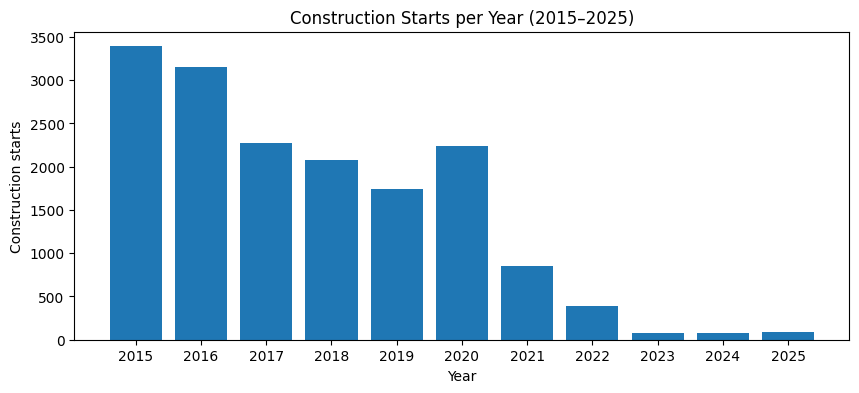

year
2015    3390
2016    3151
2017    2278
2018    2074
2019    1747
2020    2242
2021     853
2022     390
2023      77
2024      80
2025      84
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt

year_counts = construction_15_25["year"].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.bar(year_counts.index.astype(int), year_counts.values)
plt.title("Construction Starts per Year (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Construction starts")
plt.xticks(year_counts.index.astype(int), rotation=0)
plt.show()

year_counts

In [11]:
construction_overlap = construction_15_25[
    (construction_15_25["construction_start"] >= pd.to_datetime("2015-01-01")) &
    (construction_15_25["construction_start"] <= pd.to_datetime("2020-12-31"))
].copy()

print("construction_overlap shape:", construction_overlap.shape)

construction_overlap shape: (14882, 10)


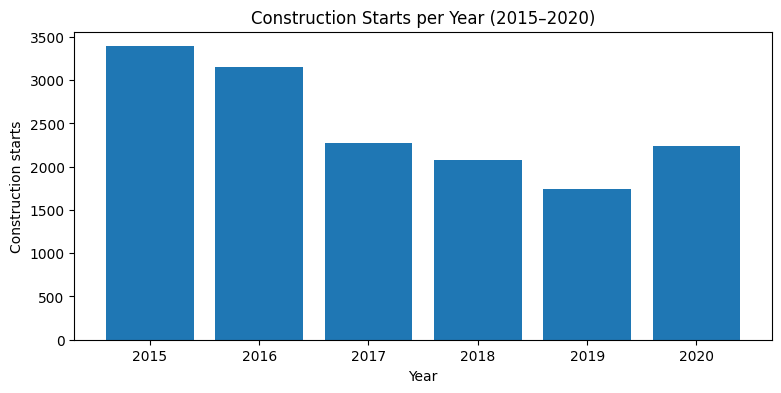

year
2015    3390
2016    3151
2017    2278
2018    2074
2019    1747
2020    2242
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Safety: make sure construction_start is datetime
construction_overlap["construction_start"] = pd.to_datetime(construction_overlap["construction_start"], errors="coerce")
dfc = construction_overlap.dropna(subset=["construction_start"]).copy()

dfc["year"] = dfc["construction_start"].dt.year
year_counts = dfc["year"].value_counts().sort_index()

plt.figure(figsize=(9,4))
plt.bar(year_counts.index.astype(int), year_counts.values)
plt.title("Construction Starts per Year (2015–2020)")
plt.xlabel("Year")
plt.ylabel("Construction starts")
plt.xticks(year_counts.index.astype(int))
plt.show()

year_counts

In [10]:
import pandas as pd
from urllib.parse import urlencode

base = "https://data.cityofnewyork.us/resource/ic3t-wcy2.csv"

select_cols = ",".join([
    "job__",
    "job_type",
    "borough",
    "gis_latitude",
    "gis_longitude",
    "pre__filing_date",
    "signoff_date"
])

def parse_mdy(s):
    s = s.astype("string").str.strip()
    return pd.to_datetime(s, format="%m/%d/%Y", errors="coerce")

limit = 50000
all_years = []

for year in range(2015, 2021):
    offset = 0
    year_chunks = []
    
    # String-based year filter (works even if pre__filing_date is treated as text)
    where = f"pre__filing_date like '%/{year}'"

    while True:
        params = {
            "$select": select_cols,
            "$where": where,
            "$limit": limit,
            "$offset": offset
        }
        url = base + "?" + urlencode(params)

        chunk = pd.read_csv(url, low_memory=False)
        if chunk.empty:
            break
        
        year_chunks.append(chunk)
        offset += limit

    if len(year_chunks) == 0:
        print(f"Year {year}: 0 rows returned")
        continue

    year_df = pd.concat(year_chunks, ignore_index=True)
    year_df["construction_start"] = parse_mdy(year_df["pre__filing_date"])
    year_df["construction_end"]   = parse_mdy(year_df["signoff_date"])
    year_df["year"] = year_df["construction_start"].dt.year

    all_years.append(year_df)
    print(f"Year {year}: rows={len(year_df)}")

if len(all_years) == 0:
    raise ValueError("No rows downloaded for 2015–2020 using LIKE. We need to inspect the API response further.")

construction_overlap = pd.concat(all_years, ignore_index=True)
construction_overlap = construction_overlap.dropna(subset=["construction_start"]).copy()

print("Final construction_overlap shape:", construction_overlap.shape)

Year 2015: rows=152351
Year 2016: rows=159640
Year 2017: rows=158676
Year 2018: rows=144689
Year 2019: rows=104768
Year 2020: rows=79340
Final construction_overlap shape: (799464, 10)


In [14]:
construction_overlap["month_num"] = pd.to_datetime(
    construction_overlap["construction_start"], errors="coerce"
).dt.month

In [15]:
construction_overlap["month_num"].value_counts(dropna=False).sort_index()

month_num
1     58139
2     59834
3     72107
4     66259
5     72781
6     77752
7     65785
8     72984
9     65661
10    69118
11    60867
12    58177
Name: count, dtype: int64

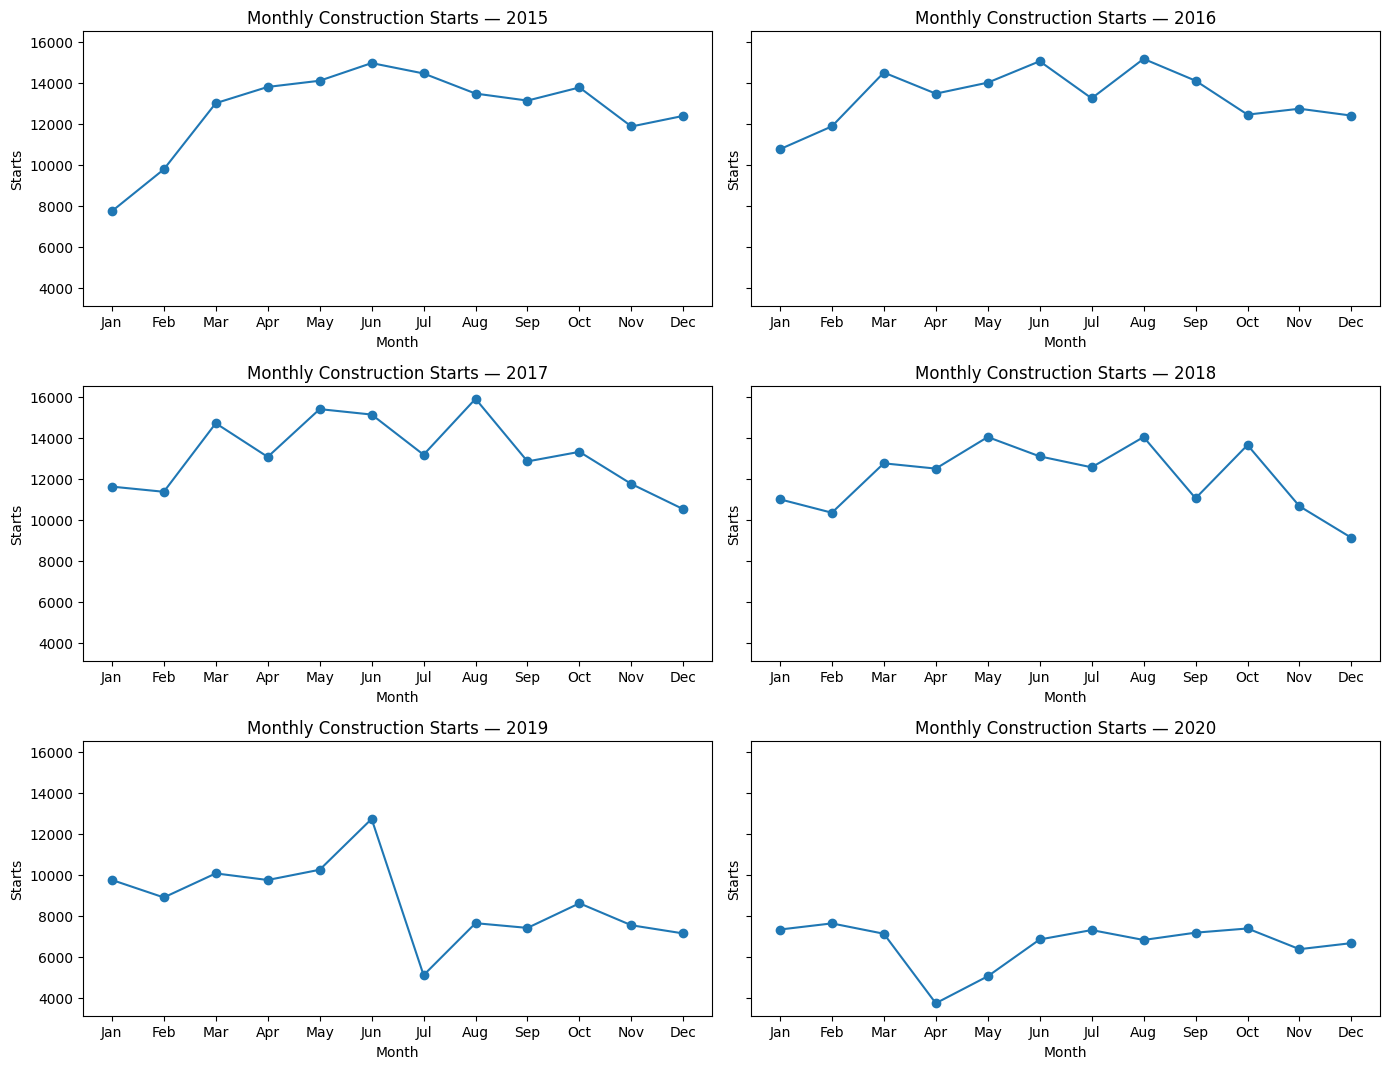

In [16]:
import numpy as np
import matplotlib.pyplot as plt

df_plot = construction_overlap.copy()

df_plot["year"] = df_plot["construction_start"].dt.year
df_plot["month_num"] = df_plot["construction_start"].dt.month

monthly_year = (
    df_plot.groupby(["year", "month_num"])
           .size()
           .reset_index(name="construction_starts")
)

years = [2015, 2016, 2017, 2018, 2019, 2020]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

ncols = 2
nrows = int(np.ceil(len(years) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 3.6*nrows), sharey=True)
axes = np.array(axes).reshape(-1)

for i, y in enumerate(years):
    ax = axes[i]
    tmp = monthly_year[monthly_year["year"] == y].copy()
    tmp = tmp.set_index("month_num").reindex(range(1, 13), fill_value=0).reset_index()

    ax.plot(tmp["month_num"], tmp["construction_starts"], marker="o")
    ax.set_title(f"Monthly Construction Starts — {y}")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_xlabel("Month")
    ax.set_ylabel("Starts")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

df = construction_overlap.copy()

# Clean borough text
df["borough"] = df["borough"].astype("string").str.strip().str.upper()

# Month bucket
df["month"] = df["construction_start"].dt.to_period("M").dt.to_timestamp()

# Count starts per borough per month
borough_month = (
    df.groupby(["borough", "month"])
      .size()
      .reset_index(name="construction_starts")
)

borough_month.head()

,borough,month,construction_starts
0,BRONX,2015-01-01,564
1,BRONX,2015-02-01,636
2,BRONX,2015-03-01,985
3,BRONX,2015-04-01,996
4,BRONX,2015-05-01,995


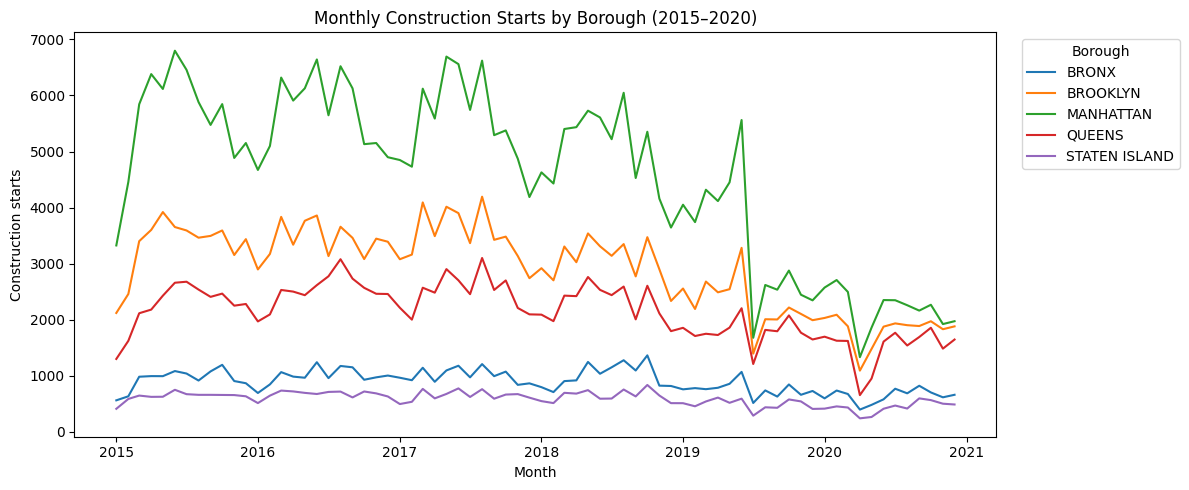

borough,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
month,,,,,
2015-01-01,564,2122,3326,1302,413
2015-02-01,636,2460,4459,1625,589
2015-03-01,985,3402,5843,2117,649
2015-04-01,996,3603,6381,2182,626
2015-05-01,995,3921,6116,2430,628


In [18]:
import matplotlib.pyplot as plt

pivot = borough_month.pivot(index="month", columns="borough", values="construction_starts").fillna(0)

plt.figure(figsize=(12,5))
for b in pivot.columns:
    plt.plot(pivot.index, pivot[b], label=b)

plt.title("Monthly Construction Starts by Borough (2015–2020)")
plt.xlabel("Month")
plt.ylabel("Construction starts")
plt.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

pivot.head()

In [19]:
import pandas as pd

# Make sure crashes exist and CRASH DATE is datetime
crashes["CRASH DATE"] = pd.to_datetime(crashes["CRASH DATE"], errors="coerce")
crashes = crashes.dropna(subset=["CRASH DATE"]).copy()

overlap_start = pd.to_datetime("2015-01-01")
overlap_end   = pd.to_datetime("2020-12-31")

crashes_overlap = crashes[
    (crashes["CRASH DATE"] >= overlap_start) &
    (crashes["CRASH DATE"] <= overlap_end)
].copy()

print("crashes_overlap:", crashes_overlap.shape)
print("range:", crashes_overlap["CRASH DATE"].min(), "→", crashes_overlap["CRASH DATE"].max())

crashes_overlap: (1234514, 29)
range: 2015-01-01 00:00:00 → 2020-12-31 00:00:00


In [20]:
# --- Crashes keys ---
crashes_overlap["year"] = crashes_overlap["CRASH DATE"].dt.year
crashes_overlap["month"] = crashes_overlap["CRASH DATE"].dt.to_period("M").dt.to_timestamp()

crashes_overlap["borough_clean"] = (
    crashes_overlap["BOROUGH"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# --- Construction keys ---
construction_overlap["year"] = construction_overlap["construction_start"].dt.year
construction_overlap["month"] = construction_overlap["construction_start"].dt.to_period("M").dt.to_timestamp()

construction_overlap["borough_clean"] = (
    construction_overlap["borough"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Quick check of borough labels
display(construction_overlap["borough_clean"].value_counts())
display(crashes_overlap["borough_clean"].value_counts().head(10))

borough_clean
MANHATTAN        328710
BROOKLYN         209191
QUEENS           154554
BRONX             64520
STATEN ISLAND     42489
Name: count, dtype: Int64

borough_clean
BROOKLYN         260494
QUEENS           224325
MANHATTAN        179239
BRONX            124118
STATEN ISLAND     31503
Name: count, dtype: Int64

In [21]:
year_crashes = crashes_overlap.groupby("year").size().reset_index(name="crashes")
year_const   = construction_overlap.groupby("year").size().reset_index(name="construction_starts")

year_join = year_crashes.merge(year_const, on="year", how="left").fillna(0)
year_join

,year,crashes,construction_starts
0,2015,217708,152351
1,2016,229832,159640
2,2017,231007,158676
3,2018,231564,144689
4,2019,211486,104768
5,2020,112917,79340


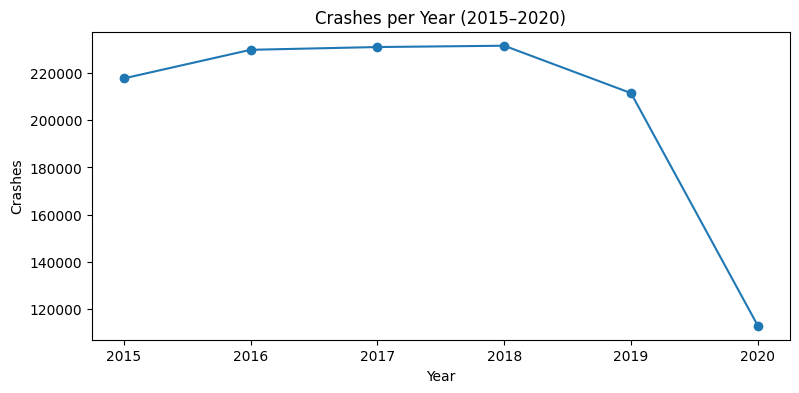

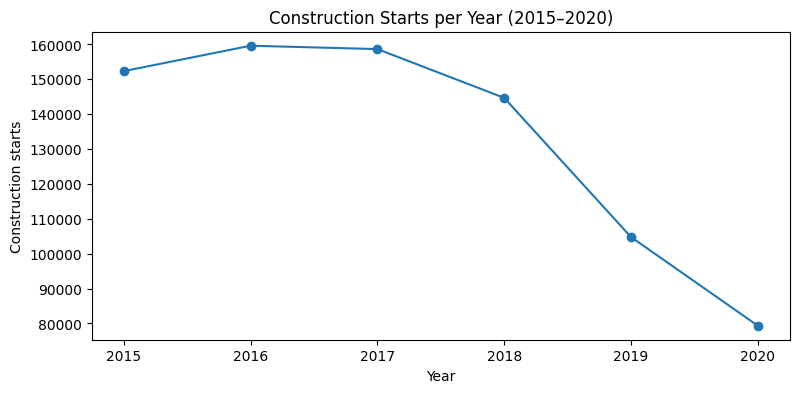

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))
plt.plot(year_join["year"], year_join["crashes"], marker="o")
plt.title("Crashes per Year (2015–2020)")
plt.xlabel("Year")
plt.ylabel("Crashes")
plt.xticks(year_join["year"])
plt.show()

plt.figure(figsize=(9,4))
plt.plot(year_join["year"], year_join["construction_starts"], marker="o")
plt.title("Construction Starts per Year (2015–2020)")
plt.xlabel("Year")
plt.ylabel("Construction starts")
plt.xticks(year_join["year"])
plt.show()

In [23]:
month_crashes = crashes_overlap.groupby("month").size().reset_index(name="crashes")
month_const   = construction_overlap.groupby("month").size().reset_index(name="construction_starts")

month_join = month_crashes.merge(month_const, on="month", how="left")
month_join["construction_starts"] = month_join["construction_starts"].fillna(0)

month_join.head()

,month,crashes,construction_starts
0,2015-01-01,16127,7727
1,2015-02-01,15714,9769
2,2015-03-01,17956,12996
3,2015-04-01,16794,13788
4,2015-05-01,19274,14090


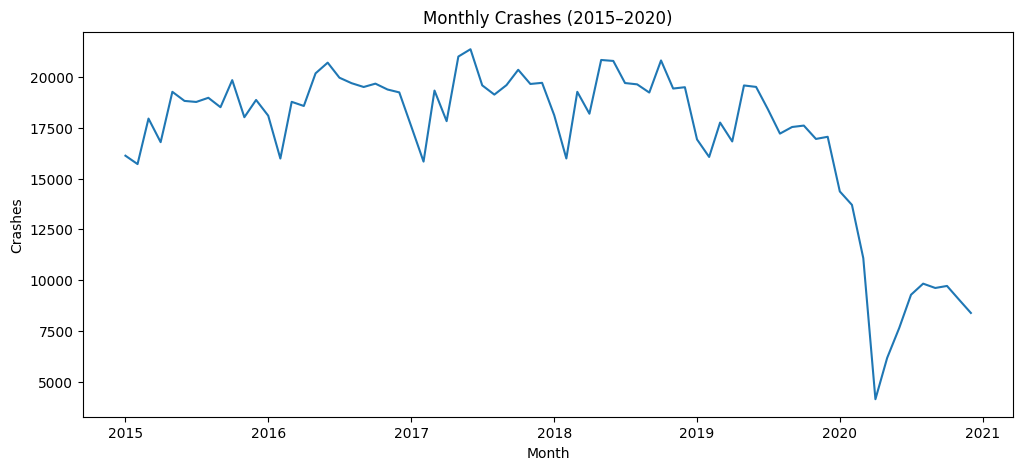

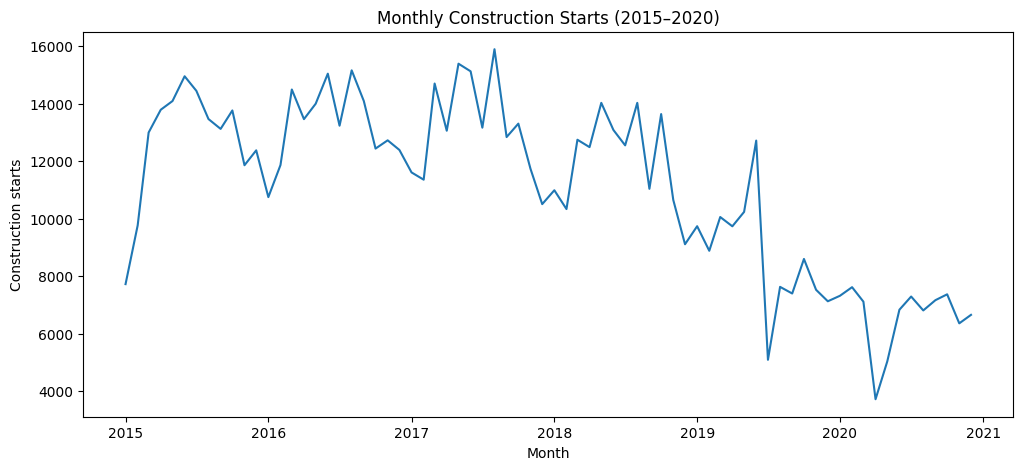

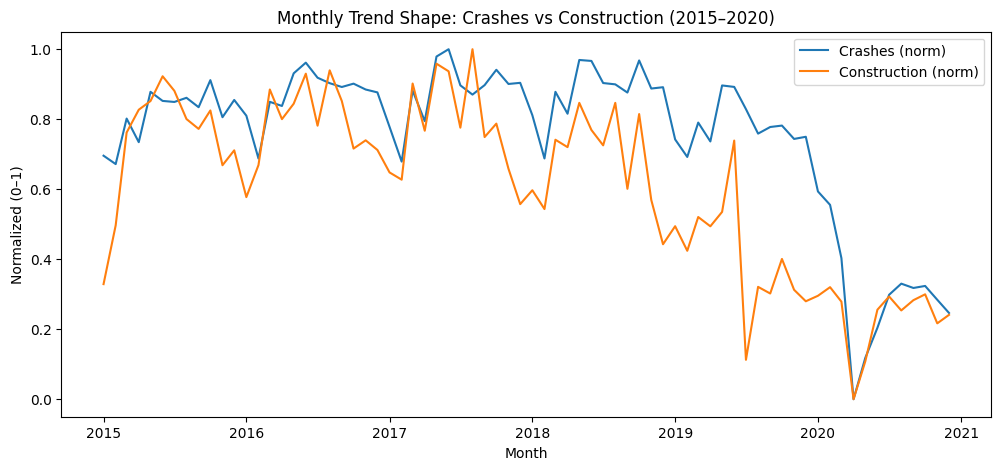

In [24]:
plt.figure(figsize=(12,5))
plt.plot(month_join["month"], month_join["crashes"])
plt.title("Monthly Crashes (2015–2020)")
plt.xlabel("Month")
plt.ylabel("Crashes")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(month_join["month"], month_join["construction_starts"])
plt.title("Monthly Construction Starts (2015–2020)")
plt.xlabel("Month")
plt.ylabel("Construction starts")
plt.show()

# Normalized overlay (shape comparison)
month_join["crashes_norm"] = (month_join["crashes"] - month_join["crashes"].min()) / (month_join["crashes"].max() - month_join["crashes"].min())
month_join["const_norm"]   = (month_join["construction_starts"] - month_join["construction_starts"].min()) / (month_join["construction_starts"].max() - month_join["construction_starts"].min())

plt.figure(figsize=(12,5))
plt.plot(month_join["month"], month_join["crashes_norm"], label="Crashes (norm)")
plt.plot(month_join["month"], month_join["const_norm"], label="Construction (norm)")
plt.title("Monthly Trend Shape: Crashes vs Construction (2015–2020)")
plt.xlabel("Month")
plt.ylabel("Normalized (0–1)")
plt.legend()
plt.show()

In [25]:
valid_boroughs = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]

boro_crashes = (
    crashes_overlap[crashes_overlap["borough_clean"].isin(valid_boroughs)]
    .groupby("borough_clean")
    .size()
    .reset_index(name="crashes")
)

boro_const = (
    construction_overlap[construction_overlap["borough_clean"].isin(valid_boroughs)]
    .groupby("borough_clean")
    .size()
    .reset_index(name="construction_starts")
)

boro_join = boro_crashes.merge(boro_const, on="borough_clean", how="left").fillna(0)
boro_join = boro_join.sort_values("crashes", ascending=False)

boro_join

,borough_clean,crashes,construction_starts
1,BROOKLYN,260494,209191
3,QUEENS,224325,154554
2,MANHATTAN,179239,328710
0,BRONX,124118,64520
4,STATEN ISLAND,31503,42489


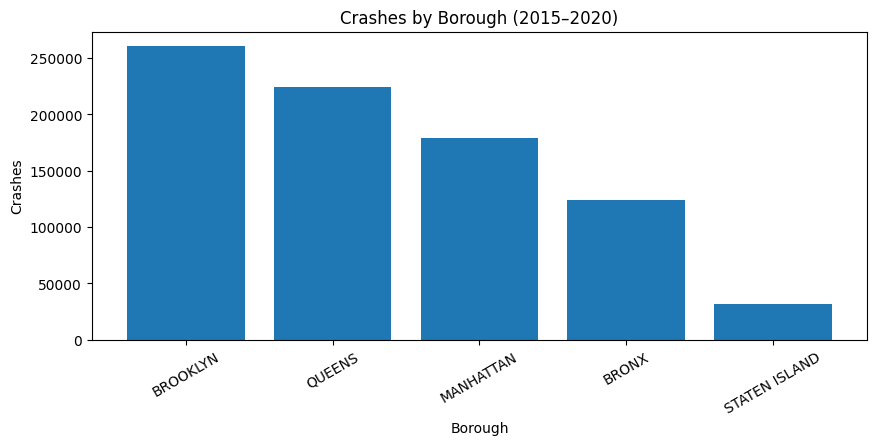

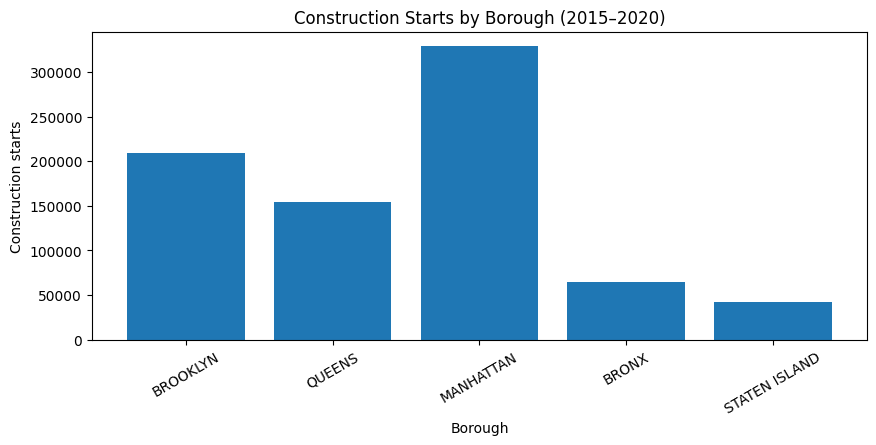

In [26]:
plt.figure(figsize=(10,4))
plt.bar(boro_join["borough_clean"], boro_join["crashes"])
plt.title("Crashes by Borough (2015–2020)")
plt.xlabel("Borough")
plt.ylabel("Crashes")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10,4))
plt.bar(boro_join["borough_clean"], boro_join["construction_starts"])
plt.title("Construction Starts by Borough (2015–2020)")
plt.xlabel("Borough")
plt.ylabel("Construction starts")
plt.xticks(rotation=30)
plt.show()

In [27]:
bm_crashes = (
    crashes_overlap[crashes_overlap["borough_clean"].isin(valid_boroughs)]
    .groupby(["borough_clean", "month"])
    .size()
    .reset_index(name="crashes")
)

bm_const = (
    construction_overlap[construction_overlap["borough_clean"].isin(valid_boroughs)]
    .groupby(["borough_clean", "month"])
    .size()
    .reset_index(name="construction_starts")
)

bm_join = bm_crashes.merge(bm_const, on=["borough_clean", "month"], how="left")
bm_join["construction_starts"] = bm_join["construction_starts"].fillna(0).astype(int)

bm_join.head()

,borough_clean,month,crashes,construction_starts
0,BRONX,2015-01-01,1704,564
1,BRONX,2015-02-01,1435,636
2,BRONX,2015-03-01,1825,985
3,BRONX,2015-04-01,1623,996
4,BRONX,2015-05-01,1839,995


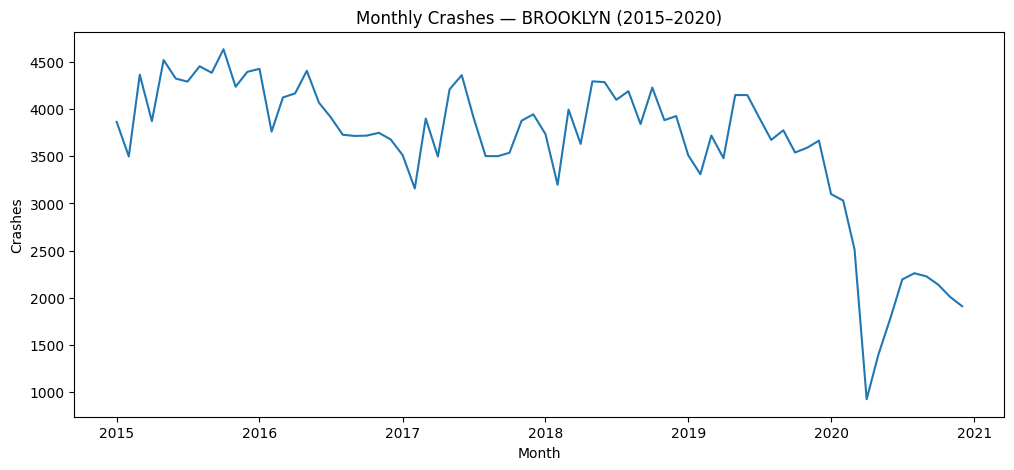

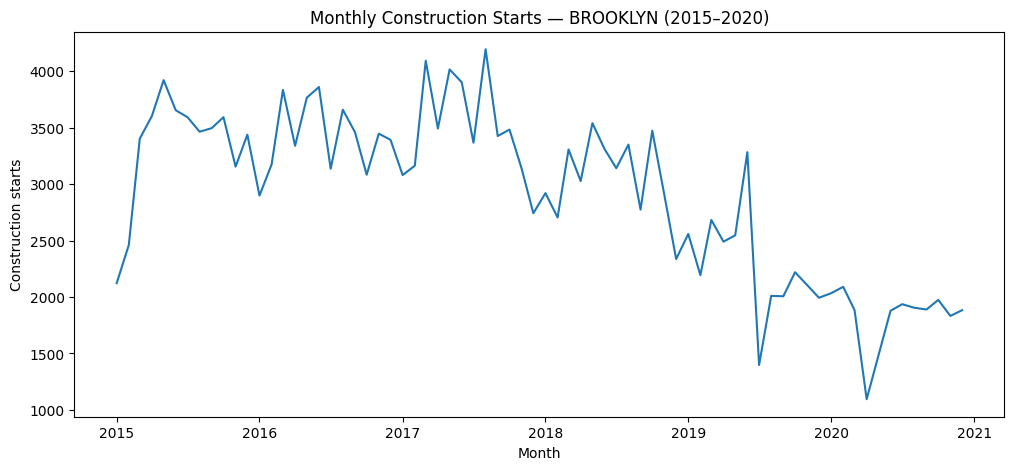

In [28]:
borough_to_plot = "BROOKLYN"  # change to BRONX, MANHATTAN, QUEENS, STATEN ISLAND

tmp = bm_join[bm_join["borough_clean"] == borough_to_plot].sort_values("month")

plt.figure(figsize=(12,5))
plt.plot(tmp["month"], tmp["crashes"])
plt.title(f"Monthly Crashes — {borough_to_plot} (2015–2020)")
plt.xlabel("Month")
plt.ylabel("Crashes")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(tmp["month"], tmp["construction_starts"])
plt.title(f"Monthly Construction Starts — {borough_to_plot} (2015–2020)")
plt.xlabel("Month")
plt.ylabel("Construction starts")
plt.show()

## Step A: Data quality & coverage (2015–2020)

Before interpreting results, we quantify:
- missing borough coverage in crashes
- coordinate coverage (crashes + construction)
- basic coordinate sanity checks

This prevents misleading borough/proximity conclusions.

In [7]:
import pandas as pd
import numpy as np

# Use overlap (2015–2020) datasets
df_cr = crashes_overlap.copy()
df_co = construction_overlap.copy()

# Ensure expected columns exist
needed_cr_cols = ["BOROUGH", "LATITUDE", "LONGITUDE",
                  "NUMBER OF PERSONS INJURED", "NUMBER OF PERSONS KILLED"]
missing_cr = [c for c in needed_cr_cols if c not in df_cr.columns]
print("Missing crash columns:", missing_cr)

needed_co_cols = ["borough", "gis_latitude", "gis_longitude", "job_type"]
missing_co = [c for c in needed_co_cols if c not in df_co.columns]
print("Missing construction columns:", missing_co)

# Borough missing in crashes
boro_missing_pct = df_cr["BOROUGH"].isna().mean() * 100
print(f"Crash BOROUGH missing: {boro_missing_pct:.1f}%")

# Coordinate coverage
crash_geo_pct = df_cr[["LATITUDE","LONGITUDE"]].notna().all(axis=1).mean() * 100
const_geo_pct = df_co[["gis_latitude","gis_longitude"]].notna().all(axis=1).mean() * 100
print(f"Crash rows with lat+lon: {crash_geo_pct:.1f}%")
print(f"Construction rows with lat+lon: {const_geo_pct:.1f}%")

NameError: name 'crashes_overlap' is not defined

In [30]:
# Sanity bounds for NYC area (approx)
cr_geo = df_cr.dropna(subset=["LATITUDE","LONGITUDE"]).copy()
co_geo = df_co.dropna(subset=["gis_latitude","gis_longitude"]).copy()

# Coerce to numeric
cr_geo["LATITUDE"] = pd.to_numeric(cr_geo["LATITUDE"], errors="coerce")
cr_geo["LONGITUDE"] = pd.to_numeric(cr_geo["LONGITUDE"], errors="coerce")
co_geo["gis_latitude"] = pd.to_numeric(co_geo["gis_latitude"], errors="coerce")
co_geo["gis_longitude"] = pd.to_numeric(co_geo["gis_longitude"], errors="coerce")

# NYC bounding-ish box
def within_nyc(lat, lon):
    return (lat.between(40.4, 41.1)) & (lon.between(-74.3, -73.6))

cr_inbox = within_nyc(cr_geo["LATITUDE"], cr_geo["LONGITUDE"]).mean() * 100
co_inbox = within_nyc(co_geo["gis_latitude"], co_geo["gis_longitude"]).mean() * 100

print(f"Crash points inside NYC bbox: {cr_inbox:.1f}%")
print(f"Construction points inside NYC bbox: {co_inbox:.1f}%")

Crash points inside NYC bbox: 99.9%
Construction points inside NYC bbox: 100.0%


##  Summary (Data Quality)

- Crash borough field is missing for **33.6%** of records → borough-level crash analysis uses only records with known borough.
- Coordinate coverage is strong:
  - **89.7%** of crashes have valid latitude/longitude
  - **99.6%** of construction records have valid latitude/longitude
- Coordinate sanity check:
  - **99.9%** of crash points fall within an NYC bounding box
  - **100.0%** of construction points fall within an NYC bounding box

**Implication:** Spatial proximity analysis (using coordinates) is reliable and may be more complete than borough-based analysis.

Monthly crashes + injuries + construction (2015–2020)

We merge monthly metrics so we can see how crash counts and injury severity move with construction activity.

Metrics:
- `crashes` (count)
- `injured_total` (sum of injuries)
- `injuries_per_crash` (severity rate)
- `construction_starts` (count)

In [4]:
import pandas as pd

# Load
crash_raw = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes_20260204.csv", low_memory=False)

# Parse date
crash_raw["CRASH DATE"] = pd.to_datetime(crash_raw["CRASH DATE"], errors="coerce")
crash_raw = crash_raw.dropna(subset=["CRASH DATE"]).copy()

# Base window (2015–2025) if you need it later
crashes = crash_raw[
    (crash_raw["CRASH DATE"] >= pd.to_datetime("2015-01-01")) &
    (crash_raw["CRASH DATE"] <= pd.to_datetime("2025-12-31"))
].copy()

# Overlap window for linking with construction (2015–2020)
overlap_start = pd.to_datetime("2015-01-01")
overlap_end   = pd.to_datetime("2020-12-31")

crashes_overlap = crashes[
    (crashes["CRASH DATE"] >= overlap_start) &
    (crashes["CRASH DATE"] <= overlap_end)
].copy()

print("crashes shape:", crashes.shape)
print("crashes_overlap shape:", crashes_overlap.shape)
print("range:", crashes_overlap["CRASH DATE"].min(), "→", crashes_overlap["CRASH DATE"].max())

crashes shape: (1722361, 29)
crashes_overlap shape: (1234514, 29)
range: 2015-01-01 00:00:00 → 2020-12-31 00:00:00


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sev["month"], monthly_sev["injured"])
plt.title("Total Injuries per Month (2015–2020)")
plt.xlabel("Month")
plt.ylabel("Total injuries")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(monthly_sev["month"], monthly_sev["killed"])
plt.title("Total Fatalities per Month (2015–2020)")
plt.xlabel("Month")
plt.ylabel("Total fatalities")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(monthly_sev["month"], monthly_sev["injuries_per_crash"])
plt.title("Injuries per Crash (2015–2020)")
plt.xlabel("Month")
plt.ylabel("Injuries per crash")
plt.show()

NameError: name 'monthly_sev' is not defined

<Figure size 1200x500 with 0 Axes>